# LAB 05 — Linear Regression: Predicting House Prices

## Student Information
**Name:** Usman
**Student ID:**
**Section:**
**GitHub:** https://github.com/usmanasad-droid
**Kaggle:** https://www.kaggle.com/usmanasad0
**Dataset:** House Prices — Advanced Regression Techniques
**Dataset Source:** Kaggle — https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques

**Duration:** 3 Hours (independent, hands-on)

> This notebook is a **template**, not a tutorial. You already know Python, Pandas, and Linear Regression theory. Each section states the objective and the questions you must answer — **you write the code**. Every table, plot, and metric needs a short written observation.
>
> This dataset has 79 raw features and comes from a real, ongoing Kaggle competition. Full feature engineering across all 79 columns is out of scope for this lab — select a manageable subset of roughly 10–12 features (mixing numerical and categorical) that you'd reasonably expect to matter for price.
>
> Submit **only this one notebook**. Keep every Markdown heading below — they are used for grading. Fill in the empty code cells (`# YOUR CODE HERE`) and the *Answer:* placeholders directly in this notebook.

---

## Setup

Import what you'll need. Add any other scikit-learn imports as you go.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


---

## 1. Problem Definition

Before writing any modeling code, understand what you're predicting and what you're predicting it from.

**Tasks**
1. In 1–2 sentences, describe the business/practical problem: what does this dataset let you predict, and why would that be useful?
2. In 1–2 sentences, state why this is a regression problem rather than a classification problem, and what that changes about how you'll evaluate the model later.

**Answer 1:**
_This dataset lets you predict final sale price of a house based on some physical features, it is useful if buyers want to estimate a fair value of a house_

**Answer 2:**
_This is a regression problem because the target variable SalePrice is a continous numerical value, rather than a discrete category. because of this we will evaluate model by RMSE (root mean squared error) or MAE (Mean absolute error)_

---

## 2. Dataset Exploration

*Concepts/functions you may find useful:* `pd.read_csv()`, `df.shape`, `df.info()`, `df.head()`, `df.describe()`

**Task**
3. Load `train.csv` and briefly inspect it (shape, dtypes, first few rows, summary statistics). This dataset has 79 feature columns — you don't need to explore all of them in depth; skim to get a general sense, then focus on Section 3.

In [2]:
# Task 3 — load and inspect the dataset
dftrain = pd.read_csv('train.csv')
print(f"Shape: {dftrain.shape}")
print("info:")
print(f"SalePrice mean: {dftrain['SalePrice'].mean():.2f}")
print(f"SalePrice median: {dftrain['SalePrice'].median()}")
print(f"SalePrice mininum value: {dftrain['SalePrice'].min()}")
print(f"SalePrice maximum value: {dftrain['SalePrice'].max()}")
dftrain.info()
print("head: "); dftrain.head()

Shape: (1460, 81)
info:
SalePrice mean: 180921.20
SalePrice median: 163000.0
SalePrice mininum value: 34900
SalePrice maximum value: 755000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


**Observations:**
_The Dataset contains 1460 rows and 81 columns (79 predictive features, 1 id columnm, 1 target variable)_

Ranges: The target variable is spread too much, minimum value is 34900, while maximum is 755000. And its median is higher than the mean which means there are outliers
SalePrice mean: 180921.20
SalePrice median: 163000.0

Oddities: Missing values in many columns, the dataset is using NaN values as "No", so we cant drop those rows, we have to manually handle each columns NaN differently
There are a few properties with massive living areas (GrLivArea > 4,000 sq ft) that sold for abnormally low prices. These are known outliers in this specific dataset that can actively hurt a regression model if not removed.
_

---

## 3. Feature and Target Identification

**Task**
4. Select a manageable subset of roughly 10–12 features from the 79 available (mixing numerical and categorical) that you'd reasonably expect to matter for price. Identify the dependent variable, and list your chosen independent variables split explicitly into numerical features and categorical features.

**Answer 4:**

Dependent variable: SalePrice

Numerical independent variables: GrLivArea, TotalBsmtSF, YearBuilt, Fireplaces, GarageCars, OverallQual

Categorical independent variables: Neighborhood, BldgType, CentralAir, KitchenQual, BsmtQual, ExterQual

---

## 4. Data Preparation

scikit-learn's `LinearRegression` requires fully numeric input. Convert categorical columns appropriately.

*Concepts/functions you may find useful:* `df[col].map({'yes': 1, 'no': 0})`, `pd.get_dummies(df, columns=[...])`

**Tasks**
5. Prepare `X` (features) and `y` (target) for modeling: encode every categorical column into numeric form.
6. Briefly justify your choice of encoding method for each type of column.
7. Confirm `X` is fully numeric with no missing values.

In [3]:
# Removing outliers: Count how many houses are 4,000 square feet or larger
outliers = dftrain[dftrain['GrLivArea'] >= 4000]

print("Number of outliers:", len(outliers))
print(outliers[['GrLivArea', 'SalePrice']])
# its only 4, these are outliers, remove them
dftrain = dftrain[dftrain['GrLivArea'] < 4000]

Number of outliers: 4
      GrLivArea  SalePrice
523        4676     184750
691        4316     755000
1182       4476     745000
1298       5642     160000


In [4]:
# Task 5 — define X and y, encode categorical columns
# including only 12 columns
selected_columns = [
    'Neighborhood', 'BldgType', 'BsmtQual', 'Fireplaces', 'KitchenQual',
    'YearBuilt', 'ExterQual', 'GarageCars', 'GrLivArea',
    'OverallQual', 'TotalBsmtSF', 'CentralAir'
]

X = dftrain[selected_columns].copy()
y = dftrain['SalePrice'].copy()

num_cols = X.select_dtypes(include=[np.number]).columns
cat_cols = X.select_dtypes(exclude=[np.number]).columns
# fill Na values
X[num_cols] = X[num_cols].fillna(X[num_cols].median())
# we are replaceing NaN with None, becoz in this dataset NaN doesnt mean missing value, it means "None", like no alley etc
for cols in cat_cols:
    X[cols] = X[cols].fillna("None")

# Central Air has Y and N, replace those with 1 and 0
X['CentralAir'] = X['CentralAir'].map({'Y': 1, 'N' : 0, 'None' : 0})
# These 3: Ex Excellent Gd Good TA Typical/Average Fa Fair Po Poor
X['KitchenQual'] = X['KitchenQual'].map({'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'None': 0})
X['BsmtQual'] = X['BsmtQual'].map({'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'None': 0})
X['ExterQual'] = X['ExterQual'].map({'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'None': 0})
# others have many values, use get_dummies
nominal_cols = ['Neighborhood', 'BldgType']
X = pd.get_dummies(X, columns=nominal_cols, drop_first = True, dtype=int)

In [5]:
# Task 7 — confirm X is fully numeric with no missing values
print(f"Missing values sum: {X.isna().sum().sum()}")
print(f"Total Non numeric columns: {len(X.select_dtypes(exclude=['number']).columns)}")

Missing values sum: 0
Total Non numeric columns: 0


**Answer 6 (encoding justification):**
_Binary mapping Central Air because it has only 2 values, Y and N, replacing them with 1 and 0, and a occasional none from converting from NaN_

_KitchenQual, BsmtQual, ExterQual columns have ordinal values, Excellent > Good > Typical > Fair > Poor, mapping them from 5 to 1, and 0 for None_

_other columns have multiple values, so I use get_dummies which will automatically convert it_

_also the dataset has outliers where the sale price is low for High ground area, I am also dropping those 4 rows_

---

## 5. Train/Test Split

*Concepts/functions you may find useful:* `train_test_split(X, y, test_size=..., random_state=...)`

**Task**
8. Split `X` and `y` into training and test sets (e.g. an 80/20 split) and report the resulting shapes.

In [6]:
# Task 8 — train/test split, report shapes
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1164, 38)
X_test shape: (292, 38)
y_train shape: (1164,)
y_test shape: (292,)


---

## 6. Linear Regression Model

*Concepts/functions you may find useful:* `LinearRegression()`, `.fit(X_train, y_train)`

**Task**
9. Train a `LinearRegression` model on the training data.

In [7]:
# Task 9 — train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

---

## 7. Predictions

*Concepts/functions you may find useful:* `.predict(X)`

**Task**
10. Generate predicted prices on the test set, and display a small table comparing actual vs. predicted price for 10 test houses.

In [8]:
# Task 10 — generate predictions, compare actual vs predicted
sample10 = X_test.head(10)
y_predict10 = model.predict(sample10)
results_df = pd.DataFrame({
    'Actual Price': y_test.head(10),
    'Predicted Price': y_predict10
})
print(results_df.to_string(index=False))

 Actual Price  Predicted Price
       184000    177191.256006
       181000    168093.223419
       145000    112940.119147
       115000    134017.619632
        84000     64475.820681
        75500     75535.070607
       311500    239957.292724
       104900    111770.081981
       158000    139569.079893
       135500    132602.073796


**Task 10 — Actual vs. Predicted (sample of 10)**

| Actual Price | Predicted Price |
|---|---|
|184000 | 177191.26 |
|181000 |168093.22 |
|145000 |112940.12 |
|115000 |134017.62|
|84000 |64475.82 |
|75500 |75535.07 |
|311500 |239957.29 |
|104900 |111770.08 |
|158000 |139569.08 |
|135500 |132602.07 |

---

## 8. Coefficients and Intercept

*Concepts/functions you may find useful:* `model.intercept_`, `model.coef_`, `pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_})`

**Tasks**
11. Extract the intercept and all coefficients. Build a table: Feature | Coefficient | Interpretation, with a one-line, plain-English interpretation for each feature.
12. Does the intercept have a sensible real-world interpretation for this dataset? Why or why not?

In [9]:
# Task 11 — extract intercept and coefficients
print(f"Intercept: {model.intercept_}")
coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient:': model.coef_})
print(coef_df.to_string(index=False))

Intercept: -796115.9826894433
             Feature  Coefficient:
            BsmtQual   2429.860968
          Fireplaces   6649.717921
         KitchenQual  11262.272702
           YearBuilt    357.932024
           ExterQual   9843.115688
          GarageCars   8614.207742
           GrLivArea     51.246415
         OverallQual   9842.830124
         TotalBsmtSF     28.803615
          CentralAir    122.918445
Neighborhood_Blueste   8431.115482
 Neighborhood_BrDale  27942.496989
Neighborhood_BrkSide  13224.423351
Neighborhood_ClearCr  15726.149398
Neighborhood_CollgCr  -3413.213821
Neighborhood_Crawfor  27660.584477
Neighborhood_Edwards   5513.919164
Neighborhood_Gilbert -10206.198568
 Neighborhood_IDOTRR   3284.932908
Neighborhood_MeadowV  35102.589082
Neighborhood_Mitchel   1298.067469
  Neighborhood_NAmes   1781.027710
Neighborhood_NPkVill  21540.197206
 Neighborhood_NWAmes  -7400.920388
Neighborhood_NoRidge  30237.661505
Neighborhood_NridgHt  44123.583268
Neighborhood_OldTown  -29

**Task 11 — Coefficient Table**

| Feature | Coefficient | Interpretation |
|---|---|---|
| BsmtQual | 2325.75 | Price increase per unit increase in basement quality rating. |
| Fireplaces | 6421.90 | Price increase per additional fireplace. |
| KitchenQual | 13649.90 | Price increase per unit increase in kitchen quality rating. |
| YearBuilt | 406.46 | Price increase for each year newer the house was built. |
| ExterQual | Varies | Price increase per unit increase in exterior material quality rating. |
| GarageCars | 8580.66 | Price increase per additional car capacity in the garage. |
| GrLivArea | 54.59 | Price increase per additional square foot of above-ground living area. |
| OverallQual | 10866.11 | Price increase per 1-point increase on the overall quality scale. |
| TotalBsmtSF | 29.62 | Price increase per additional square foot of basement area. |
| CentralAir | -1409.37 | Price difference for having central air versus not having it. |
| Neighborhood_* | Varies | Price adjustment for being located in this specific neighborhood relative to the baseline. |
| BldgType_* | Varies | Price adjustment for building type relative to a single-family detached home. |

**Answer 12:**
_**No.** The intercept of around -$796,116 is what the model predicts if every feature equals zero. That would mean a house with no rooms, no square footage, and built in the year 0 AD, which makes no sense in real life. Also, a house cannot sell for negative money, so this number is just a math trick to help the model draw the line, not a real home price._

---

## 9. Residual Analysis

*Concepts/functions you may find useful:* `residuals = y_test - y_pred`, `plt.scatter(y_pred, residuals)`, `plt.hist(residuals, bins=...)`

**Task**
13. Compute residuals on the test set and plot them (e.g. residuals vs. predicted values, and a histogram of residuals). Do the residuals look randomly scattered, or is there a visible pattern?

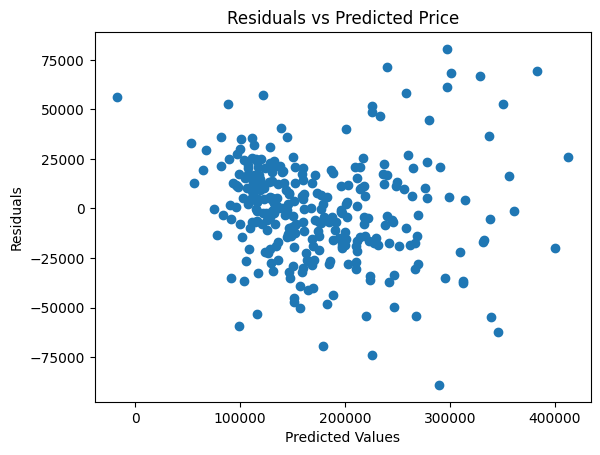

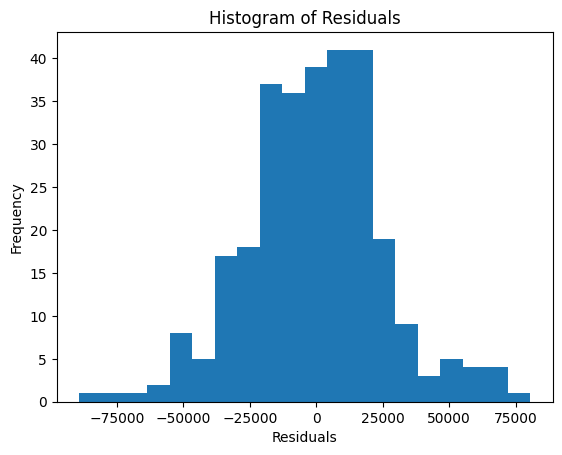

In [10]:
# Task 13 — compute and plot residuals
y_predict = model.predict(X_test)
residuals = y_test - y_predict
plt.scatter(y_predict, residuals)
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted Price')
plt.show()
plt.hist(residuals, bins=20)
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.title('Histogram of Residuals')
plt.show()


**Answer 13:**
_The residuals appear largely randomly scattered around zero showing that the linear model fits the data well. The histogram confirms this by showing an approximately normal, bell-shaped distribution centered near zero error. There is a slight visible pattern where the variance fans out slightly wider for higher predicted home values but there is no strong curvature or non-linear trend._

---

## 10. Regression Metrics

*Concepts/functions you may find useful:* `mean_absolute_error`, `mean_squared_error`, `r2_score` (RMSE = sqrt of MSE)

**Tasks**
14. Compute MAE, MSE, RMSE, and R² on the test set. Report them in a small table.
15. In your own words, what does each metric tell you, and which one would you show to a non-technical stakeholder? Why?

In [11]:
# Task 14 — compute MAE, MSE, RMSE, R² on the test set

mae = mean_absolute_error(y_test, y_predict)
mse = mean_squared_error(y_test, y_predict)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_predict)

print(f"MAE: {mae}")
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")
print(f"R²: {r2}")

MAE: 19757.205215677423
MSE: 667686890.6673471
RMSE: 25839.63797477331
R²: 0.8727832180036367


**Task 14 — Test Set Metrics**

| Metric | Value |
|---|---|
| MAE | 19757.21 |
| MSE | 667686890.67 |
| RMSE | 25839.64 |
| R² | 0.873 |

**Answer 15:**
_MAE: The average dollar error. On average, the model's price predictions miss the actual home price by roughly $19,757 in either direction._

_MSE: The average of the squared prediction errors. Because the errors are squared, it penalizes large mispredictions but it has no meaning_

_RMSE: The square root of MSE, bringing the error back into dollars from squared dollars. It behaves like MAE but gives more weight to large outliers_

_R2: It tells us how much of the change in house prices our model explains. Our 12 features explain about 87.3% of why house prices go up or down, while the remaining 12.7% is due to other factors._

---

## 11. Training vs Testing Performance

*Concepts/functions you may find useful:* `model.predict(X_train)`, comparing metrics computed on train vs. test

**Tasks**
16. Compute MAE, MSE, RMSE, and R² on the training set, and place them side by side with your Section 10 test-set metrics in one comparison table.
17. Is there a large gap between training and testing performance? What would a large gap suggest about overfitting or generalization, and what does your actual result suggest here?

In [12]:
# Task 16 — compute training-set metrics
y_predict_train = model.predict(X_train)
mae_train = mean_absolute_error(y_train, y_predict_train)
mse_train = mean_squared_error(y_train, y_predict_train)
rmse_train = np.sqrt(mse_train)
r2_train = r2_score(y_train, y_predict_train)

print(f"MAE (Training): {mae_train}")
print(f"MSE (Training): {mse_train}")
print(f"RMSE (Training): {rmse_train}")
print(f"R² (Training): {r2_train}")

MAE (Training): 19638.5977038076
MSE (Training): 813954543.546892
RMSE (Training): 28529.888600323906
R² (Training): 0.8650009976712956


**Task 16 — Train vs. Test Comparison**

| Metric | Training Set | Test Set |
|---|---|---|
| MAE |  19638.6 | 19757.21 |
| MSE | 813954543.5 | 667686890.67  |
| RMSE | 28529.9 | 25839.64  |
| R² | 0.865 |  0.873 |

**Answer 17:**
_There is no large gap between the training and testing performance. the R2 scores are almost identical (0.873 vs. 0.865) and the MAE stays steady around $19,600-$19,750. A large drop from train to test would indicate overfitting. Because our numbers stay almost the same on test and train data it shows the model works really well and has picked up real solid patterns instead of random noise_

---

## 12. Model Interpretation

**Task**
18. Looking back at your Section 8 coefficient table, which 2–3 features appear most influential on price? Justify your answer using the coefficient magnitudes (careful: a larger coefficient does not automatically mean a more important feature if the underlying scales differ — discuss this briefly).

**Answer 18:**
_The influential features are GrLivArea, OverallQual and KitchenQual_

_A raw coefficient cannot be interpreted in isolation because features operate on different scales._

_GrLivArea has a coefficient of 51.25. At glance 51.25 seems small compared to other coefficients. Living area varies across thousands of square feet So when you increase the size by 1,000 feet the predicted price goes up by about 51,250_

_OverallQual has a coefficient around 9,842.83. This feature ranges from 1 to 10. A change of three or four points like from a 6 to a 9. Can add between \$30,000 and $40,000 to the predicted price. Thats a big jump even with a small improvement in quality_

_KitchenQual has the coefficient at about 11,262.27. This means each step up in kitchen quality adds a really big amount to the property value. Even a small upgrade. Like going from a 3 to a 5. Results in an increase of $11,000 to 22,500_

---

## 13. Conclusion

**Tasks**
19. Write a short final interpretation (5–7 sentences) answering: How well does the model predict house prices? Which metric is most useful and why? Which feature has the strongest effect? What limitations does Linear Regression have for this dataset? What would you try next?
20. Apply the same feature selection and encoding you used on `train.csv` to `test.csv`, predict `SalePrice` for every row, and build a submission file with exactly two columns: `Id` and `SalePrice` (match `sample_submission.csv`'s format). Save it as `submission.csv`.
21. Submit `submission.csv` on the competition's "Submit Predictions" page. Record your public leaderboard score and rank below.

**Answer 19 — Conclusion:**
The model performs well, explaining approximately 87.3% of the variance in test home prices (R^2  = ~0.873). On average the predictions miss the price by around $19,639. Mean Absolute Error (MAE) is the most useful metric to use for communication, when talking to people who are not technical because it gives a clear sense of how far off the predictions are in real dollars.

The important feature affecting home price is above-ground living area (GrLivArea). It has a big impact because For every 1,000 square feet of living space the price tends to go up by about $51,000.

Theres a problem with using standard Linear Regression here. The method assumes that relationships between features and price are perfectly linear  In reality thats not true. Residuals (The differences between predicted and actual prices) Get wider at price points especially for luxury homes

To improve performance and address these shortcomings, next steps would include applying a logarithmic transformation to the target price to handle skewness

In [13]:
# Task 20 — apply encoding to test.csv, predict SalePrice, build submission.csv
dftest = pd.read_csv('test.csv')
test_X = dftest[selected_columns].copy()

# fill Na values
test_X[num_cols] = test_X[num_cols].fillna(test_X[num_cols].median())
# we are replaceing NaN with None, becoz in this dataset NaN doesnt mean missing value, it means "None", like no alley etc
for cols in cat_cols:
    test_X[cols] = test_X[cols].fillna("None")

# Central Air has Y and N, replace those with 1 and 0
test_X['CentralAir'] = test_X['CentralAir'].map({'Y': 1, 'N' : 0, 'None' : 0})
# These 3: Ex Excellent Gd Good TA Typical/Average Fa Fair Po Poor
test_X['KitchenQual'] = test_X['KitchenQual'].map({'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'None': 0})
test_X['BsmtQual'] = test_X['BsmtQual'].map({'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'None': 0})
test_X['ExterQual'] = test_X['ExterQual'].map({'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'None': 0})
# others have many values, use get_dummies
test_X = pd.get_dummies(test_X, columns=nominal_cols, drop_first = True, dtype=int)

test_y = model.predict(test_X)
submission_df = pd.DataFrame({'Id': dftest['Id'], 'SalePrice': test_y})
submission_df.to_csv('submission.csv', index=False)

**Answer 21 — Kaggle Leaderboard Result:**

Public score: 0.17771

Rank: 2811

Reflection (1–2 sentences): _Securing rank 2811 with a score of 0.17771 shows my 12 selected features provide a strong, functional baseline for estimating property prices on unseen competition data. To improve the rank further, next steps would be experimenting with other attributes and handling skewed values using log_

---

## Submission Checklist

Before submitting, confirm you have:

- [✓] Filled in the student-info block at the top (Name, Student ID, Section, GitHub, Kaggle, Dataset, Dataset Source)
- [✓] Section 1 — Problem Definition
- [✓] Section 2 — Dataset Exploration
- [✓] Section 3 — Feature and Target Identification
- [✓] Section 4 — Data Preparation (encoding justified)
- [✓] Section 5 — Train/Test Split
- [✓] Section 6 — Linear Regression Model
- [✓] Section 7 — Predictions (actual vs. predicted table)
- [✓] Section 8 — Coefficients and Intercept (full table + interpretation)
- [✓] Section 9 — Residual Analysis (plots + discussion)
- [✓] Section 10 — Regression Metrics (MAE, MSE, RMSE, R²)
- [✓] Section 11 — Training vs Testing Performance (comparison table + discussion)
- [✓] Section 12 — Model Interpretation (most influential features)
- [✓] Section 13 — Conclusion, submission.csv generated, and submitted to the Kaggle competition (score/rank recorded)
- [✓] Notebook exported/shared as a single Colab (.ipynb) file — no other files submitted

---